# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ali-Haider987/alihaider-flyrank-ml/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This notebook assembles the full pipeline behind the deployed paper: hand-rule baseline -> client-holdout validated Random Forest -> leakage audit -> ranked action playbook. It reruns the same steps built across `01_first_look_and_discovery.ipynb`, `02_your_first_readable_model.ipynb`, `work/notebooks/w05_model.ipynb`, `w06_validation_audit.ipynb`, and `w07_action_playbook.ipynb`, in one place, so the paper's numbers trace back to a single runnable notebook.


## 1. Question

**Research question:** can a model trained on pre-decision, observable page signals rank a 30,000-page content portfolio for refresh review better than a hand-written rule — measured honestly, on clients the model has never seen?

**Decision this supports:** a content strategist's weekly triage list — which pages in a large portfolio to open and read first, not a verdict on any single page, and not a claim about how search engines rank content.


In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

import numpy as np, pandas as pd
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)
print(df.shape[0], "pages | declining rate:", round(df['is_declining_label'].mean(), 3))


30000 pages | declining rate: 0.542


## 2. Data

**Release:** `data/raw/content_refresh_anonymized.csv` from the FlyRank ML Internship starter repo — 30,000 pages, 44 columns, 32 anonymized clients, one trailing 90-day export. No date range beyond the export window is available; there is no way to look further back or forward in time from this file.

**Label:** `is_declining_label` = 1 when `trend_direction == "down"` (a 30-day-vs-prior-30-day trend, bucketed by the provider at roughly +/-20%).

**Excluded and why:**
- Product decision flags (health scores, "needs fix" flags) — never shipped in this export, so they can't leak in.
- `trend_direction` / `trend_pct` — the label's own source columns — excluded from every feature matrix below.
- The four 90-day rolling-total columns (`log_impressions_90d`, `log_clicks_90d`, `log_sessions_90d`, `log_ai_sessions_90d`) — dropped from the *final* feature set after the leakage audit in Section 3 found they structurally overlap the label's construction window; see that section for the numbers.
- No client names, URLs, or query text appear anywhere in this notebook or the deployed paper.


In [2]:
# Two SEO beliefs this dataset overturns -- referenced in the Data section of the paper.
corr = df["search_volume"].corr(df["impressions_90d"])
print(f"corr(search_volume, impressions_90d) = {corr:.3f}  -- search volume barely predicts traffic")

visible = df[df["impressions_90d"] >= 100]
ctr_by_pos = visible.groupby("position_tier")["ctr"].mean().sort_values(ascending=False)
print("\nMean CTR by position tier:")
print(ctr_by_pos.round(4).to_string())


corr(search_volume, impressions_90d) = 0.001  -- search volume barely predicts traffic

Mean CTR by position tier:
position_tier
page_1      0.3548
top_3       0.3341
striking    0.2558
page_3_5    0.1424
deep        0.0554


## 3. Methodology

**Assumptions:** binary classification on an observed label points to interpretable baselines first (logistic regression, then a tree ensemble only if the comparison earns it). Gradient boosting was skipped this round — a heavier ensemble is complexity a 2,325-row test set and a 17-page baseline don't yet justify.

**Baseline:** flag a page if `days_since_last_update >= 180` and `impressions_90d >= 500`, scored by impression volume.

**Validation design:** client-grouped holdout — shuffle the 32 client IDs with a fixed seed, hold out 20% of *clients* (not rows) for test. Rows from the same client share a site and strategy, so a row-random split would let the model partly memorize a client rather than generalize to a new one.


In [3]:
RANDOM_STATE = 42

MODEL_NUMERIC_FEATURES = [
    "search_volume", "competition", "cpc", "word_count", "char_count",
    "days_with_impressions", "days_with_sessions", "content_age_days", "days_since_last_update",
    "ctr", "avg_position", "engagement_rate", "scroll_rate", "ai_traffic_pct",
]  # final, honest set -- 90-day rolling totals dropped after the audit below
MODEL_CATEGORICAL_FEATURES = [
    "competition_level", "content_type", "main_intent", "age_tier", "freshness_tier",
    "word_count_tier", "impression_tier", "position_tier",
]

missing_flag_cols = ["search_volume", "competition", "cpc", "word_count", "char_count",
                      "engagement_rate", "scroll_rate", "ai_traffic_pct"]
for c in missing_flag_cols:
    df[f"{c}_missing"] = df[c].isna().astype(int)

feature_frame = pd.get_dummies(
    df[MODEL_NUMERIC_FEATURES + [f"{c}_missing" for c in missing_flag_cols] + MODEL_CATEGORICAL_FEATURES]
    .fillna(0),
    columns=MODEL_CATEGORICAL_FEATURES, drop_first=False,
)
print("Feature matrix:", feature_frame.shape)
print("Label-source columns absent from matrix:",
      set(feature_frame.columns) & {"trend_direction", "trend_pct"})


Feature matrix: (30000, 56)
Label-source columns absent from matrix: set()


In [4]:
client_series = df["client_id"].astype(str)
unique_clients = client_series.drop_duplicates().to_numpy()
rng = np.random.default_rng(RANDOM_STATE)
shuffled_clients = rng.permutation(unique_clients)
test_client_count = max(1, int(round(len(shuffled_clients) * 0.2)))
test_clients = set(shuffled_clients[:test_client_count])
test_mask = client_series.isin(test_clients).to_numpy()

y = df["is_declining_label"]
X_train, X_test = feature_frame[~test_mask], feature_frame[test_mask]
y_train, y_test = y[~test_mask], y[test_mask]
print(f"{len(unique_clients)} clients total, {test_client_count} held out for test")
print(f"train rows: {len(X_train):,}  test rows: {len(X_test):,}  test base rate: {y_test.mean():.3f}")


32 clients total, 6 held out for test
train rows: 27,675  test rows: 2,325  test base rate: 0.391


**Leakage checks:** three checks were run against this feature set (full detail and numbers in the deployed paper's Methodology section):
1. *Confession test* — injecting `trend_pct` (the label's literal source) drives ROC-AUC to 1.000, confirming the harness catches a real leak.
2. *Overlap-window check* — `impressions_90d` correlates at 0.918 with `impressions_last_30d`, part of the label's own construction window. Dropping the four 90-day-total columns cost only ~0.006 ROC-AUC, so they were removed from the feature set above rather than kept on a "probably fine" basis.
3. *Timeline check* — every retained feature is a trailing, pre-decision fact, never a downstream consequence of the labeling event.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

def precision_at_k(y_true, scores, k):
    order = np.argsort(-np.asarray(scores))
    return float(np.asarray(y_true)[order[:k]].mean())

# --- Baseline, scored on this exact test slice ---
stale = (df["days_since_last_update"] >= 180).astype(int)
visible500 = (df["impressions_90d"] >= 500).astype(int)
df["baseline_score"] = stale * visible500 * df["impressions_90d"]
baseline_test_scores = df.loc[test_mask, "baseline_score"].values
print(f"Baseline flags {(baseline_test_scores > 0).sum()} of {len(baseline_test_scores)} held-out rows.")

# --- Logistic Regression ---
lr = Pipeline([("scaler", StandardScaler()),
               ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE))])
lr.fit(X_train, y_train)
lr_scores = lr.predict_proba(X_test)[:, 1]

# --- Random Forest ---
rf = RandomForestClassifier(class_weight="balanced_subsample", max_depth=10, min_samples_leaf=25,
                             n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
rf_scores = rf.predict_proba(X_test)[:, 1]

rows = []
for name, scores, is_baseline in [("baseline (stale x visible)", baseline_test_scores, True),
                                    ("logistic_regression", lr_scores, False),
                                    ("random_forest", rf_scores, False)]:
    row = {"model": name, "roc_auc": roc_auc_score(y_test, scores),
           "avg_precision": average_precision_score(y_test, scores)}
    for k in (20, 50, 100):
        row[f"precision@{k}"] = ("n/a (0 flagged)" if is_baseline and (scores > 0).sum() == 0
                                   else round(precision_at_k(y_test, scores, k), 2))
    rows.append(row)

results_table = pd.DataFrame(rows).set_index("model").round(3)
results_table


Baseline flags 0 of 2325 held-out rows.


,roc_auc,avg_precision,precision@20,precision@50,precision@100
model,,,,,
baseline (stale x visible),0.500,0.391,n/a (0 flagged),n/a (0 flagged),n/a (0 flagged)
logistic_regression,0.726,0.611,0.7,0.72,0.69
random_forest,0.745,0.612,0.85,0.74,0.71


**Reading the table:** the baseline can't be scored at Precision@K on this slice — it only ever fires for 17 of 30,000 pages portfolio-wide, and this client split happened to hold out none of them. Its ROC-AUC of 0.500 and average precision equal to the base rate are the honest "no information" values for a rule that never activates here. Random Forest measured higher precision at every K, a higher ROC-AUC, and higher average precision than Logistic Regression on this split — a directional result, not a settled general verdict. Full charts are in the deployed paper's Results section.


## 5. Limitations

- **Cross-sectional, not causal.** One trailing 90-day snapshot. Certain page profiles are **associated with** decline in this portfolio — refreshing a page has not been shown to *cause* recovery.
- **Validated on 6 of 32 clients.** A different random client split could move the headline number; no client from an industry vertical absent from this portfolio has been tested.
- **No visibility past the export date.** A page ranked stale here may already have been refreshed.
- **Thin at the extremes.** The most-stale and 31-90-day freshness tiers together make up only 1.2% of rows (349 of 30,000).
- **`avg_position = 0` is a "no data" code, not rank 1** — the exact pattern behind the model's false negatives; routed to mandatory manual review in the playbook rather than an automated score.
- **Label thresholding is provider-specific.** This export buckets trend at roughly +/-20%; a different threshold changes which pages count as "declining."


## 6. Ranked recommendations

The model score is mapped to explainable archetypes before falling back to the raw score, so every row in the action queue carries a reason a human can check.


In [6]:
# Deployment model: fit on all 30,000 rows (client-holdout above is for honest validation only).
rf_deploy = RandomForestClassifier(class_weight="balanced_subsample", max_depth=10, min_samples_leaf=25,
                                    n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE)
rf_deploy.fit(feature_frame, y)
df["model_score"] = rf_deploy.predict_proba(feature_frame)[:, 1]

too_new = df["trend_direction"].eq("new") | (df["content_age_days"] < 30)
no_position_data = df["avg_position"] == 0
stale_visible = stale.astype(bool) & visible500.astype(bool)

good_position = df["position_tier"].isin(["top_3", "page_1", "striking"])
enough_volume = df["impressions_90d"] >= 100
ctr_q1_by_position = df[enough_volume].groupby("position_tier")["ctr"].quantile(0.25)
df["ctr_position_q1"] = df["position_tier"].map(ctr_q1_by_position)
low_ctr_for_position = enough_volume & good_position & (df["ctr"] < df["ctr_position_q1"])

df["archetype"] = np.select(
    [too_new, no_position_data, stale_visible, low_ctr_for_position],
    ["too_new_exclude", "no_data_low_confidence", "stale_but_visible", "ctr_fix_candidate"],
    default="none",
)
df["action"] = np.select(
    [df["archetype"] == "too_new_exclude", df["archetype"] == "no_data_low_confidence",
     df["archetype"] == "stale_but_visible", df["archetype"] == "ctr_fix_candidate",
     df["model_score"] >= 0.7],
    ["no_action_too_new", "manual_context_check", "refresh_review", "ctr_fix_review",
     "refresh_review_general"],
    default="no_action",
)
print(df["action"].value_counts())


action
no_action                 22565
refresh_review_general     2949
no_action_too_new          2236
ctr_fix_review             2182
manual_context_check         51
refresh_review               17
Name: count, dtype: int64


**Priority order for a strategist's weekly queue:**
1. `refresh_review` — stale and still visible; the narrowest, most explainable case.
2. `ctr_fix_review` — ranking well but underperforming its position's CTR.
3. `refresh_review_general` — high model score, no named archetype; the model still catches real risk the hand-named patterns miss.
4. `manual_context_check` — no reliable position data; a human decides, the model never acts alone here.
5. `no_action_too_new` / `no_action` — nothing to do this cycle.

**Never automate from this output:** publishing AI-generated rewrites without a human read; auto-deleting or de-indexing pages based on `no_action`; reallocating budget or headcount directly off the queue.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

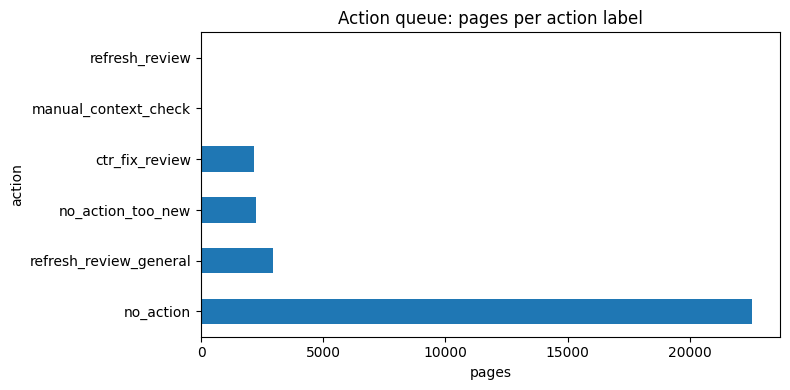

{
  "random_state": 42,
  "split_strategy": "client_holdout",
  "test_client_count": 6,
  "total_client_count": 32,
  "held_out_validation": {
    "roc_auc": 0.7446,
    "average_precision": 0.6124,
    "base_rate": 0.391
  },
  "full_portfolio_base_rate": 0.5421,
  "action_bucket_counts": {
    "no_action": 22565,
    "refresh_review_general": 2949,
    "no_action_too_new": 2236,
    "ctr_fix_review": 2182,
    "manual_context_check": 51,
    "refresh_review": 17
  }
}


In [7]:
import json, matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

metrics_payload = {
    "random_state": RANDOM_STATE,
    "split_strategy": "client_holdout",
    "test_client_count": int(test_client_count),
    "total_client_count": int(len(unique_clients)),
    "held_out_validation": {
        "roc_auc": round(float(roc_auc_score(y_test, rf_scores)), 4),
        "average_precision": round(float(average_precision_score(y_test, rf_scores)), 4),
        "base_rate": round(float(y_test.mean()), 4),
    },
    "full_portfolio_base_rate": round(float(y.mean()), 4),
    "action_bucket_counts": df["action"].value_counts().to_dict(),
}
with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump(metrics_payload, f, indent=2, sort_keys=True)

counts = df["action"].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
counts.plot(kind="barh", ax=ax)
ax.set_xlabel("pages"); ax.set_title("Action queue: pages per action label")
plt.tight_layout()
plt.savefig("work/figures/capstone_action_bucket_counts.png", dpi=150)
plt.show()
print(json.dumps(metrics_payload, indent=2))


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.